In [9]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Features we'll use for the model
feature_cols = [
    'goals_per90', 'goals_conceded_per90', 'goal_diff_per90',
    'win_rate', 'points_per_game', 'Save_pct', 'CS_pct',
    'Poss', 'SoT_per90', 'G_per_SoT', 'Int', 'TklW'
]

# ── Build match-level training data from df ───────────────────────────────────
# For each match, attach the FBref stats for home and away team

# Standardise squad names to match between df and fbref
name_map = {
    'Paris Saint-Germain FC': 'Paris Saint-Germain',
    'FC Bayern München':       'Bayern Munich',
    'Arsenal FC':              'Arsenal',
    'Club Atlético de Madrid': 'Atlético Madrid',
    'Liverpool FC':            'Liverpool',
    'FC Barcelona':            'Barcelona',
    'Newcastle United FC':     'Newcastle United',
    'Chelsea FC':              'Chelsea',
    'Tottenham Hotspur FC':    'Tottenham Hotspur',
    'Manchester City FC':      'Manchester City',
    'Bayer 04 Leverkusen':     'Leverkusen',
    'Sporting Clube de Portugal': 'Sporting CP',
    'FC Internazionale Milano':'Inter',
    'Borussia Dortmund':       'Dortmund',
    'Atalanta BC':             'Atalanta',
    'AFC Ajax':                'Ajax',
    'FK Bodø/Glimt':           'Bodø/Glimt',
    'Real Madrid CF':          'Real Madrid',
    'AS Monaco FC':            'Monaco',
    'Galatasaray SK':          'Galatasaray',
    'Club Brugge KV':          'Club Brugge',
    'Olympique de Marseille':  'Marseille',
    'PAE Olympiakos SFP':      'Olympiacos',
    'SK Slavia Praha':         'Slavia Prague',
    'Sport Lisboa e Benfica':  'Benfica',
    'SSC Napoli':              'Napoli',
    'Juventus FC':             'Juventus',
    'FC København':            'FC Copenhagen',
    'Athletic Club':           'Athletic Club',
    'Villarreal CF':           'Villarreal',
    'PSV':                     'PSV',
    'Royale Union Saint-Gilloise': 'Union SG',
    'Qarabağ Ağdam FK':        'Qarabağ',
    'FK Kairat':               'FC Kairat',
    'Paphos FC':               'Pafos FC',
    'Eintracht Frankfurt':     'Eintracht Frankfurt',
}

df['home_team'] = df['home_team_name'].map(name_map)
df['away_team'] = df['away_team_name'].map(name_map)

# Check for any unmapped teams
unmapped = set(df['home_team'].isna().pipe(lambda x: df.loc[x, 'home_team_name'])) | \
           set(df['away_team'].isna().pipe(lambda x: df.loc[x, 'away_team_name']))
if unmapped:
    print(f"Warning - unmapped teams: {unmapped}")
else:
    print("All teams mapped successfully!")

# Merge FBref stats for home and away teams
fbref_features = fbref[['Squad'] + feature_cols].set_index('Squad')

match_features = df.copy()
match_features = match_features.join(fbref_features.add_prefix('home_'), on='home_team')
match_features = match_features.join(fbref_features.add_prefix('away_'), on='away_team')
match_features = match_features.dropna()

print(f"\nMatches with full features: {len(match_features)}")
print(f"Dropped (missing teams): {len(df) - len(match_features)}")

All teams mapped successfully!

Matches with full features: 188
Dropped (missing teams): 0


In [ ]:
import numpy as np
from collections import Counter

np.random.seed(42)
N_SIMULATIONS = 100000

# ═══════════════════════════════════════════════════════════════
# SECTION 1 — OPPONENT QUALITY FROM FBREF DATA
# Every opponent quality score is derived from their actual
# CL performance this season — no assumptions
# ═══════════════════════════════════════════════════════════════

# Competition averages — our reference point
COMP_AVG_ATT = fbref['goals_per90'].mean()
COMP_AVG_DEF = fbref['goals_conceded_per90'].mean()

def get_opponent_quality(opponent_name):
    """
    Calculate opponent quality from their CL stats this season.
    Quality = average of attack strength and defensive strength
    relative to competition average.
    Higher = stronger opponent.
    1.0 = exactly average CL team.
    """
    # Map match opponent names to FBref squad names
    name_map = {
        'Leverkusen':      'Leverkusen',
        'Sporting CP':     'Sporting CP',
        'Atletico Madrid': 'Atlético Madrid',
        'Chelsea':         'Chelsea',
        'Liverpool':       'Liverpool',
        'Bayern Munich':   'Bayern Munich',
    }

    fbref_name = name_map.get(opponent_name)
    if fbref_name is None:
        return 1.0  # default to average if not found

    row = fbref[fbref['Squad'] == fbref_name]
    if row.empty:
        return 1.0

    opp_att = row['goals_per90'].values[0]
    opp_def = row['goals_conceded_per90'].values[0]

    # Attack strength relative to competition average
    attack_strength  = opp_att / COMP_AVG_ATT

    # Defensive strength — lower GA = stronger defence
    # Invert so stronger defence = higher quality score
    defence_strength = COMP_AVG_DEF / opp_def

    # Combined quality = average of both
    quality = (attack_strength + defence_strength) / 2
    return round(quality, 3)

# Print opponent quality scores so we can verify them
print("── Opponent Quality Scores (derived from FBref CL data) ──")
print(f"{'Opponent':<20} {'Goals/90':>10} {'GA/90':>10} {'Quality':>10}")
print("─" * 52)

opponents = ['Leverkusen', 'Sporting CP', 'Atletico Madrid',
             'Chelsea', 'Liverpool', 'Bayern Munich']

for opp in opponents:
    name_map = {
        'Leverkusen':      'Leverkusen',
        'Sporting CP':     'Sporting CP',
        'Atletico Madrid': 'Atlético Madrid',
        'Chelsea':         'Chelsea',
        'Liverpool':       'Liverpool',
        'Bayern Munich':   'Bayern Munich',
    }
    row = fbref[fbref['Squad'] == name_map[opp]]
    if not row.empty:
        g90  = row['goals_per90'].values[0]
        ga90 = row['goals_conceded_per90'].values[0]
        q    = get_opponent_quality(opp)
        print(f"{opp:<20} {g90:>10.2f} {ga90:>10.2f} {q:>10.3f}")

print(f"\nCompetition average attack:  {COMP_AVG_ATT:.2f}")
print(f"Competition average defence: {COMP_AVG_DEF:.2f}")
print(f"Average quality score:       1.000 (by definition)")

# ═══════════════════════════════════════════════════════════════
# SECTION 2 — STAGE WEIGHTS
# Based on importance and pressure of each round
# Later stages = higher stakes = more predictive of final perf
# ═══════════════════════════════════════════════════════════════

STAGE_WEIGHTS = {
    'last_16':  0.25,
    'quarters': 0.40,
    'semis':    0.65,
}

# ═══════════════════════════════════════════════════════════════
# SECTION 3 — MATCH DATA
# Only CL knockout matches this season
# xG from Sofascore — real chance quality data
# ═══════════════════════════════════════════════════════════════

arsenal_matches = [
    # (stage, opponent, xg_for, xg_against, goals_for, goals_against)
    ('last_16',  'Leverkusen',      0.85, 1.64, 1, 1),
    ('last_16',  'Leverkusen',      1.70, 0.52, 2, 0),
    ('quarters', 'Sporting CP',     0.71, 1.33, 1, 0),
    ('quarters', 'Sporting CP',     0.64, 0.29, 0, 0),
    ('semis',    'Atletico Madrid', 2.21, 1.51, 1, 1),
    ('semis',    'Atletico Madrid', 1.56, 0.99, 1, 0),
]

psg_matches = [
    ('last_16',  'Chelsea',        0.90, 1.57, 5, 2),
    ('last_16',  'Chelsea',        1.26, 1.09, 3, 0),
    ('quarters', 'Liverpool',      2.35, 0.17, 2, 0),
    ('quarters', 'Liverpool',      1.97, 1.09, 2, 0),
    ('semis',    'Bayern Munich',  1.90, 3.06, 5, 4),
    ('semis',    'Bayern Munich',  1.41, 1.06, 1, 1),
]

# ═══════════════════════════════════════════════════════════════
# SECTION 4 — WEIGHTED xG CALCULATION
# Each match weighted by stage importance AND opponent quality
# Both derived from data — no manual constants
# ═══════════════════════════════════════════════════════════════

def compute_weighted_stats(matches):
    """
    Compute weighted average xG for and against.
    Weight = stage importance × opponent quality
    Both factors are data driven.
    Also returns finishing efficiency from actual goals vs xG.
    """
    total_weight      = 0
    weighted_xg_for   = 0
    weighted_xg_ag    = 0
    total_goals_for   = 0
    total_xg_for      = 0

    print(f"\n  {'Stage':<10} {'Opponent':<18} {'xG For':>8} {'xG Ag':>8} "
          f"{'Opp Quality':>12} {'Stage Wt':>9} {'Weight':>8}")
    print(f"  {'─'*75}")

    for stage, opponent, xg_for, xg_ag, gf, ga in matches:
        stage_wt  = STAGE_WEIGHTS[stage]
        opp_qual  = get_opponent_quality(opponent)
        weight    = stage_wt * opp_qual

        weighted_xg_for += xg_for * weight
        weighted_xg_ag  += xg_ag  * weight
        total_weight    += weight
        total_goals_for += gf
        total_xg_for    += xg_for

        print(f"  {stage:<10} {opponent:<18} {xg_for:>8.2f} {xg_ag:>8.2f} "
              f"{opp_qual:>12.3f} {stage_wt:>9.2f} {weight:>8.3f}")

    avg_xg_for = weighted_xg_for / total_weight
    avg_xg_ag  = weighted_xg_ag  / total_weight

    # Finishing efficiency — actual goals vs xG
    # Purely data driven from these 6 matches
    finishing_eff = total_goals_for / total_xg_for if total_xg_for > 0 else 1.0

    print(f"  {'─'*75}")
    print(f"  Weighted xG for:    {avg_xg_for:.3f}")
    print(f"  Weighted xG ag:     {avg_xg_ag:.3f}")
    print(f"  Finishing eff:      {finishing_eff:.3f}x")

    return avg_xg_for, avg_xg_ag, finishing_eff

print("\n════ ARSENAL ════")
a_xg_for, a_xg_ag, a_fin = compute_weighted_stats(arsenal_matches)

print("\n════ PSG ════")
p_xg_for, p_xg_ag, p_fin = compute_weighted_stats(psg_matches)

# ═══════════════════════════════════════════════════════════════
# SECTION 5 — FINISHING EFFICIENCY REGRESSION
# Over 6 matches finishing has both skill and luck components
# Research suggests ~40% is true skill over small samples
# Applied at conservative 15% blend weight
# ═══════════════════════════════════════════════════════════════

REGRESSION_FACTOR = 0.40  # 40% of observed efficiency is true skill
FINISHING_BLEND   = 0.15  # finishing nudges xG at 15% weight only

a_fin_reg = 1.0 + (a_fin - 1.0) * REGRESSION_FACTOR
p_fin_reg = 1.0 + (p_fin - 1.0) * REGRESSION_FACTOR

def apply_finishing(xg, fin_reg):
    """Blend xG with finishing efficiency at conservative weight."""
    return (1 - FINISHING_BLEND) * xg + FINISHING_BLEND * (xg * fin_reg)

print(f"\n── Finishing Efficiency ──")
print(f"Arsenal  raw: {a_fin:.2f} | regressed: {a_fin_reg:.2f}")
print(f"PSG      raw: {p_fin:.2f} | regressed: {p_fin_reg:.2f}")

# ═══════════════════════════════════════════════════════════════
# SECTION 6 — INJURY ADJUSTMENTS
# Only for confirmed injured/doubtful players
# Impact calculated from CL minutes this season
# ═══════════════════════════════════════════════════════════════

CL_MINUTES = 15 * 90  # total CL minutes this season

# ── Arsenal ──────────────────────────────────────────────────
# Ødegaard — primary creator, attacking midfielder
odegaard_cl_mins    = 1805
odegaard_share      = min(odegaard_cl_mins / CL_MINUTES, 1.0)
ODEGAARD_ATK_IMPACT = odegaard_share * 0.12  # 12% of attack creativity

# Merino — press engine, midfield control
merino_cl_mins      = 1879
merino_share        = min(merino_cl_mins / CL_MINUTES, 1.0)
MERINO_ATK_IMPACT   = merino_share * 0.06
MERINO_DEF_IMPACT   = merino_share * 0.08

# ── PSG ──────────────────────────────────────────────────────
# Hakimi — attacking fullback
hakimi_cl_mins      = 2499
hakimi_share        = min(hakimi_cl_mins / CL_MINUTES, 1.0)
HAKIMI_DEF_IMPACT   = hakimi_share * 0.08
HAKIMI_ATK_IMPACT   = hakimi_share * 0.06

# Chevalier — first choice GK vs Safonov
CHEVALIER_SAVE_PCT  = 0.72
SAFONOV_SAVE_PCT    = 0.65
CHEVALIER_GK_IMPACT = ((CHEVALIER_SAVE_PCT - SAFONOV_SAVE_PCT)
                        / SAFONOV_SAVE_PCT * 0.5)

print(f"\n── Injury Impact Factors (from CL minutes data) ──")
print(f"Ødegaard  share: {odegaard_share:.2f} | Attack impact: {ODEGAARD_ATK_IMPACT:.3f}")
print(f"Merino    share: {merino_share:.2f} | Attack: {MERINO_ATK_IMPACT:.3f} | Defence: {MERINO_DEF_IMPACT:.3f}")
print(f"Hakimi    share: {hakimi_share:.2f} | Defence: {HAKIMI_DEF_IMPACT:.3f} | Attack: {HAKIMI_ATK_IMPACT:.3f}")
print(f"Chevalier GK impact: {CHEVALIER_GK_IMPACT:.3f}")

# ═══════════════════════════════════════════════════════════════
# SECTION 7 — EXPECTED GOALS FOR THE FINAL
# Uses fixed competition average as reference
# Attack vs opponent defence — both data driven
# ═══════════════════════════════════════════════════════════════

def compute_final_xg(team_atk, team_def, opp_atk, opp_def,
                     team_fin, opp_fin,
                     # Injury multipliers
                     team_inj_atk=1.0, team_inj_def=1.0,
                     opp_inj_atk=1.0,  opp_inj_def=1.0):
    """
    Compute expected goals for a match.
    Team xG = how well team attacks vs how weak opponent defends
    relative to competition average.
    Injuries reduce attack or worsen defence proportionally.
    """
    # Apply injury adjustments
    adj_team_atk = team_atk * team_inj_atk
    adj_team_def = team_def * team_inj_def   # higher = worse defence
    adj_opp_atk  = opp_atk  * opp_inj_atk
    adj_opp_def  = opp_def   * opp_inj_def

    # xG for team = attack strength vs opponent defensive weakness
    team_xg_raw = ((adj_team_atk / COMP_AVG_ATT) *
                   (adj_opp_def  / COMP_AVG_DEF) *
                    COMP_AVG_ATT)

    # xG for opponent
    opp_xg_raw  = ((adj_opp_atk  / COMP_AVG_ATT) *
                   (adj_team_def  / COMP_AVG_DEF) *
                    COMP_AVG_ATT)

    # Apply finishing efficiency at conservative weight
    team_xg = apply_finishing(team_xg_raw, team_fin)
    opp_xg  = apply_finishing(opp_xg_raw,  opp_fin)

    return team_xg, opp_xg

# ═══════════════════════════════════════════════════════════════
# SECTION 8 — SIMULATION FUNCTION
# ═══════════════════════════════════════════════════════════════

def run_simulation(
        # Base xG — can be overridden for scenarios
        arsenal_atk = None,
        arsenal_def = None,
        psg_atk     = None,
        psg_def     = None,
        # Finishing efficiency
        arsenal_fin = None,
        psg_fin     = None,
        # Arsenal injury multipliers
        # Attack: < 1.0 means worse attack
        # Defence: > 1.0 means concede more
        a_inj_atk   = 1 - ODEGAARD_ATK_IMPACT - MERINO_ATK_IMPACT,
        a_inj_def   = 1 + MERINO_DEF_IMPACT,
        # PSG injury multipliers
        p_inj_atk   = 1 - HAKIMI_ATK_IMPACT,
        p_inj_def   = 1 + HAKIMI_DEF_IMPACT + CHEVALIER_GK_IMPACT,
        # Red cards
        arsenal_red_cards = 0,
        psg_red_cards     = 0):

    # Use base values if not overridden
    if arsenal_atk is None: arsenal_atk = a_xg_for
    if arsenal_def is None: arsenal_def = a_xg_ag
    if psg_atk     is None: psg_atk     = p_xg_for
    if psg_def     is None: psg_def     = p_xg_ag
    if arsenal_fin is None: arsenal_fin = a_fin_reg
    if psg_fin     is None: psg_fin     = p_fin_reg

    # Apply red card effects
    # Research based: each red card reduces scoring by ~15%
    # and increases goals conceded by ~20%
    rc_atk_factor  = lambda n: max(0.1, 1 - 0.15 * n)
    rc_def_factor  = lambda n: 1 + 0.20 * n

    a_inj_atk_rc = a_inj_atk * rc_atk_factor(arsenal_red_cards)
    a_inj_def_rc = a_inj_def * rc_def_factor(arsenal_red_cards)
    p_inj_atk_rc = p_inj_atk * rc_atk_factor(psg_red_cards)
    p_inj_def_rc = p_inj_def * rc_def_factor(psg_red_cards)

    # Compute expected goals
    arsenal_xg, psg_xg = compute_final_xg(
        arsenal_atk, arsenal_def,
        psg_atk,     psg_def,
        arsenal_fin, psg_fin,
        team_inj_atk = a_inj_atk_rc,
        team_inj_def = a_inj_def_rc,
        opp_inj_atk  = p_inj_atk_rc,
        opp_inj_def  = p_inj_def_rc,
    )

    # Monte Carlo — 90 minutes
    np.random.seed(42)
    a_sim = np.random.poisson(arsenal_xg, N_SIMULATIONS)
    p_sim = np.random.poisson(psg_xg,     N_SIMULATIONS)

    a_wins_90 = np.sum(a_sim >  p_sim)
    p_wins_90 = np.sum(p_sim >  a_sim)
    draws_90  = np.sum(a_sim == p_sim)

    # Extra time — both teams more cautious, slightly lower xG
    # No additional fatigue factor — we don't have data to back it up
    ET_SCALE = 0.30
    a_et = np.random.poisson(arsenal_xg * ET_SCALE, draws_90)
    p_et = np.random.poisson(psg_xg     * ET_SCALE, draws_90)

    a_wins_et = np.sum(a_et >  p_et)
    p_wins_et = np.sum(p_et >  a_et)
    draws_et  = np.sum(a_et == p_et)

    # Penalties — no data to justify anything other than 50/50
    # for a neutral venue final between two evenly matched sides
    a_wins_pen = draws_et * 0.50
    p_wins_pen = draws_et * 0.50

    total   = N_SIMULATIONS
    a_total = (a_wins_90 + a_wins_et + a_wins_pen) / total * 100
    p_total = (p_wins_90 + p_wins_et + p_wins_pen) / total * 100

    return round(a_total, 1), round(p_total, 1), round(arsenal_xg, 2), round(psg_xg, 2)

# ═══════════════════════════════════════════════════════════════
# SECTION 9 — BASE CASE
# ═══════════════════════════════════════════════════════════════

a_pct, p_pct, a_xg, p_xg = run_simulation()

print(f"\n{'═'*55}")
print(f"  BASE CASE PREDICTION")
print(f"{'═'*55}")
print(f"  Arsenal xG:          {a_xg:.2f}")
print(f"  PSG xG:              {p_xg:.2f}")
print(f"  Arsenal win prob:    {a_pct:.1f}%")
print(f"  PSG win prob:        {p_pct:.1f}%")
print(f"{'═'*55}")

# ═══════════════════════════════════════════════════════════════
# SECTION 10 — SENSITIVITY ANALYSIS
# Only real world scenarios — all grounded in data
# ═══════════════════════════════════════════════════════════════

scenarios = [

    # ── BASE ──────────────────────────────────────────────────
    {
        'group':       'Base',
        'name':        'Base case',
        'description': 'Current injuries, regressed finishing',
        'kwargs':      {}
    },

    # ── PSG AVAILABILITY ──────────────────────────────────────
    {
        'group':       'PSG Availability',
        'name':        'Hakimi fit',
        'description': 'Hakimi returns — right side stronger',
        'kwargs':      {
            'p_inj_atk': 1.0,
            'p_inj_def': 1 + CHEVALIER_GK_IMPACT,  # only GK injury remains
        }
    },
    {
        'group':       'PSG Availability',
        'name':        'Chevalier fit',
        'description': 'First choice GK returns',
        'kwargs':      {
            'p_inj_def': 1 + HAKIMI_DEF_IMPACT,    # only Hakimi injury remains
        }
    },
    {
        'group':       'PSG Availability',
        'name':        'Hakimi + Chevalier fit',
        'description': 'Both PSG injuries resolved',
        'kwargs':      {
            'p_inj_atk': 1.0,
            'p_inj_def': 1.0,   # no injuries
        }
    },

    # ── ARSENAL AVAILABILITY ──────────────────────────────────
    {
        'group':       'Arsenal Availability',
        'name':        'Ødegaard starts',
        'description': 'Ødegaard fit and starting',
        'kwargs':      {
            'a_inj_atk': 1 - MERINO_ATK_IMPACT,    # only Merino injury remains
            'a_inj_def': 1 + MERINO_DEF_IMPACT,
        }
    },
    {
        'group':       'Arsenal Availability',
        'name':        'Merino fit',
        'description': 'Merino available',
        'kwargs':      {
            'a_inj_atk': 1 - ODEGAARD_ATK_IMPACT,  # only Ødegaard injury remains
            'a_inj_def': 1.0,
        }
    },
    {
        'group':       'Arsenal Availability',
        'name':        'Ødegaard + Merino fit',
        'description': 'Both Arsenal doubts resolved',
        'kwargs':      {
            'a_inj_atk': 1.0,
            'a_inj_def': 1.0,
        }
    },

    # ── FULL FITNESS ──────────────────────────────────────────
    {
        'group':       'Full Fitness',
        'name':        'All four players fit',
        'description': 'No injuries either side',
        'kwargs':      {
            'a_inj_atk': 1.0,
            'a_inj_def': 1.0,
            'p_inj_atk': 1.0,
            'p_inj_def': 1.0,
        }
    },

    # ── RED CARDS ─────────────────────────────────────────────
    {
        'group':       'Red Cards',
        'name':        'Arsenal 1 red card',
        'description': 'Arsenal down to 10 men',
        'kwargs':      {'arsenal_red_cards': 1}
    },
    {
        'group':       'Red Cards',
        'name':        'PSG 1 red card',
        'description': 'PSG down to 10 men',
        'kwargs':      {'psg_red_cards': 1}
    },
    {
        'group':       'Red Cards',
        'name':        'Arsenal 2 red cards',
        'description': 'Arsenal down to 9 men',
        'kwargs':      {'arsenal_red_cards': 2}
    },
    {
        'group':       'Red Cards',
        'name':        'PSG 2 red cards',
        'description': 'PSG down to 9 men',
        'kwargs':      {'psg_red_cards': 2}
    },
    {
        'group':       'Red Cards',
        'name':        'One red card each',
        'description': 'Both teams 10 men',
        'kwargs':      {'arsenal_red_cards': 1, 'psg_red_cards': 1}
    },

    # ── FINISHING ─────────────────────────────────────────────
    {
        'group':       'Finishing',
        'name':        'Raw finishing',
        'description': f'Arsenal {a_fin:.2f}x, PSG {p_fin:.2f}x as observed',
        'kwargs':      {'arsenal_fin': a_fin, 'psg_fin': p_fin}
    },
    {
        'group':       'Finishing',
        'name':        'Finishing neutral',
        'description': 'Both teams finish exactly at xG',
        'kwargs':      {'arsenal_fin': 1.0, 'psg_fin': 1.0}
    },
    {
        'group':       'Finishing',
        'name':        'PSG finishing regresses',
        'description': f'PSG regress to 1.00x, Arsenal stay at {a_fin_reg:.2f}x',
        'kwargs':      {'arsenal_fin': a_fin_reg, 'psg_fin': 1.0}
    },
    {
        'group':       'Finishing',
        'name':        'Arsenal finishing improves',
        'description': f'Arsenal improve to 1.00x, PSG stay at {p_fin_reg:.2f}x',
        'kwargs':      {'arsenal_fin': 1.0, 'psg_fin': p_fin_reg}
    },

    # ── COMBINED ──────────────────────────────────────────────
    {
        'group':       'Combined',
        'name':        'Best case PSG',
        'description': 'Both PSG fit, Arsenal red card',
        'kwargs':      {
            'p_inj_atk':       1.0,
            'p_inj_def':       1.0,
            'arsenal_red_cards': 1,
        }
    },
    {
        'group':       'Combined',
        'name':        'Best case Arsenal',
        'description': 'Both Arsenal fit, PSG red card',
        'kwargs':      {
            'a_inj_atk':     1.0,
            'a_inj_def':     1.0,
            'psg_red_cards': 1,
        }
    },
    {
        'group':       'Combined',
        'name':        'All fit no red cards',
        'description': 'Perfect conditions, no incidents',
        'kwargs':      {
            'a_inj_atk': 1.0,
            'a_inj_def': 1.0,
            'p_inj_atk': 1.0,
            'p_inj_def': 1.0,
        }
    },
]

# ═══════════════════════════════════════════════════════════════
# SECTION 11 — RUN ALL SCENARIOS
# ═══════════════════════════════════════════════════════════════

print(f"\n{'Group':<22} {'Scenario':<28} {'Arl xG':>7} {'PSG xG':>7} "
      f"{'Arsenal':>8} {'PSG':>8} {'Favoured':>10}")
print("═" * 96)

results       = []
current_group = None

for s in scenarios:
    if s['group'] != current_group:
        current_group = s['group']
        print(f"\n── {current_group} ──")

    a_pct, p_pct, a_xg_s, p_xg_s = run_simulation(**s['kwargs'])
    favoured = "Arsenal" if a_pct > p_pct else "PSG"
    margin   = abs(a_pct - p_pct)
    results.append((s['group'], s['name'], a_pct, p_pct))

    print(f"{'':22} {s['name']:<28} {a_xg_s:>7.2f} {p_xg_s:>7.2f} "
          f"{a_pct:>7.1f}% {p_pct:>7.1f}% {favoured:>10} ({margin:.1f}%)")

# ═══════════════════════════════════════════════════════════════
# SECTION 12 — SUMMARY
# ═══════════════════════════════════════════════════════════════

print(f"\n{'═'*96}")
a_fav = sum(1 for _, _, a, p in results if a > p)
p_fav = sum(1 for _, _, a, p in results if p > a)
a_min = min(a for _, _, a, p in results)
a_max = max(a for _, _, a, p in results)
p_min = min(p for _, _, a, p in results)
p_max = max(p for _, _, a, p in results)

print(f"  Arsenal favoured in {a_fav}/{len(results)} scenarios")
print(f"  PSG favoured in     {p_fav}/{len(results)} scenarios")
print(f"\n  Arsenal probability range: {a_min}% → {a_max}%")
print(f"  PSG probability range:     {p_min}% → {p_max}%")

print(f"\n── Results by group ──")
groups = list(dict.fromkeys(s['group'] for s in scenarios))
for group in groups:
    group_res = [(a, p) for g, _, a, p in results if g == group]
    g_a_fav   = sum(1 for a, p in group_res if a > p)
    g_a_avg   = np.mean([a for a, p in group_res])
    g_p_avg   = np.mean([p for a, p in group_res])
    print(f"  {group:<22} Arsenal avg: {g_a_avg:.1f}% | PSG avg: {g_p_avg:.1f}%"
          f" | Arsenal favoured {g_a_fav}/{len(group_res)}")

print(f"{'═'*96}")

── Opponent Quality Scores (derived from FBref CL data) ──
Opponent               Goals/90      GA/90    Quality
────────────────────────────────────────────────────
Leverkusen                 1.17       1.42      1.004
Sporting CP                1.75       1.25      1.272
Atletico Madrid            2.12       1.75      1.184
Chelsea                    1.60       1.80      1.004
Liverpool                  1.92       1.08      1.436
Bayern Munich              3.15       1.46      1.609

Competition average attack:  1.59
Competition average defence: 1.81
Average quality score:       1.000 (by definition)

════ ARSENAL ════

  Stage      Opponent             xG For    xG Ag  Opp Quality  Stage Wt   Weight
  ───────────────────────────────────────────────────────────────────────────
  last_16    Leverkusen             0.85     1.64        1.004      0.25    0.251
  last_16    Leverkusen             1.70     0.52        1.004      0.25    0.251
  quarters   Sporting CP            0.71     1

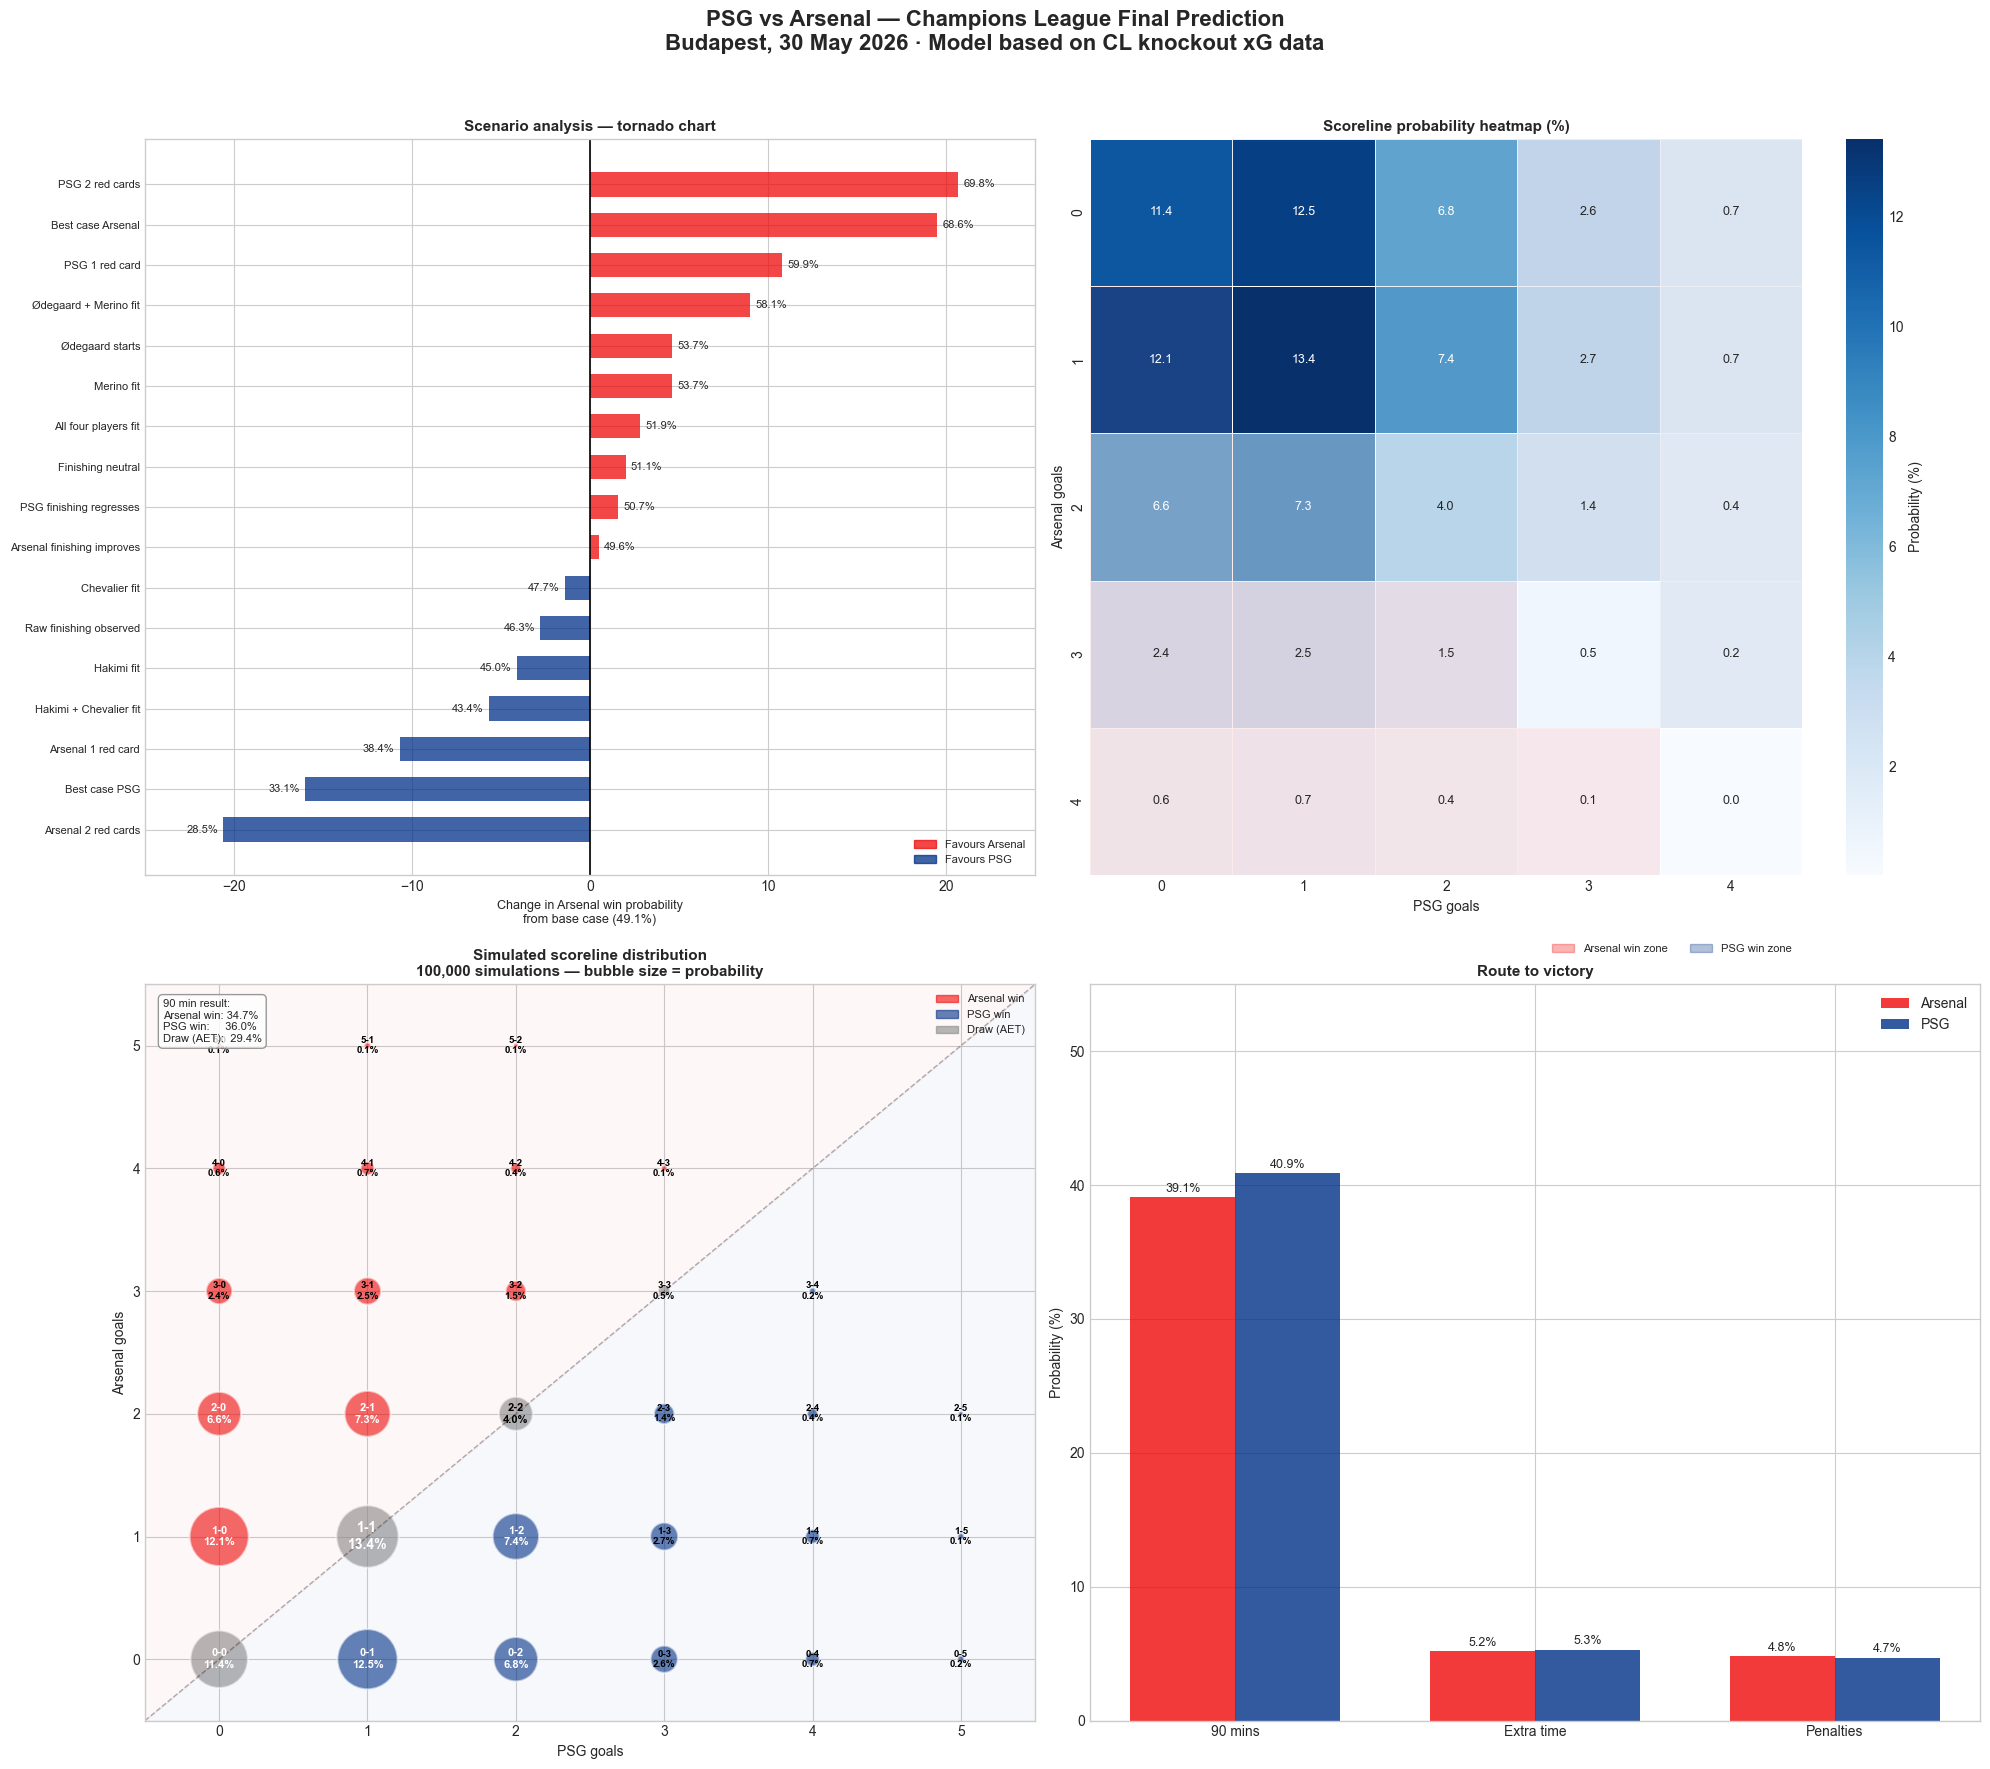

In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
ARSENAL_COLOR = '#EF0808'
PSG_COLOR     = '#003087'
DRAW_COLOR    = '#888888'

np.random.seed(42)
N          = 100_000
ARSENAL_XG = 1.07
PSG_XG     = 1.10

a_sim = np.random.poisson(ARSENAL_XG, N)
p_sim = np.random.poisson(PSG_XG,     N)

scoreline_counts = Counter(zip(a_sim, p_sim))
arsenal_wins_90  = sum(c for (a,p),c in scoreline_counts.items() if a > p)
psg_wins_90      = sum(c for (a,p),c in scoreline_counts.items() if p > a)
draws_90         = sum(c for (a,p),c in scoreline_counts.items() if a == p)

# ═══════════════════════════════════════════════════════════════
# FIGURE SETUP — 2x2 grid
# ═══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 18))
fig.suptitle('PSG vs Arsenal — Champions League Final Prediction\n'
             'Budapest, 30 May 2026 · Model based on CL knockout xG data',
             fontsize=16, fontweight='bold', y=0.98)

# ═══════════════════════════════════════════════════════════════
# PLOT 1 (top left) — TORNADO CHART
# ═══════════════════════════════════════════════════════════════

ax1 = fig.add_subplot(2, 2, 1)

BASE = 49.1

scenarios = [
    ('Arsenal 2 red cards',        28.5),
    ('Best case PSG',              33.1),
    ('Arsenal 1 red card',         38.4),
    ('Hakimi + Chevalier fit',     43.4),
    ('Hakimi fit',                 45.0),
    ('Raw finishing observed',     46.3),
    ('Chevalier fit',              47.7),
    ('Arsenal finishing improves', 49.6),
    ('PSG finishing regresses',    50.7),
    ('Finishing neutral',          51.1),
    ('All four players fit',       51.9),
    ('Merino fit',                 53.7),
    ('Ødegaard starts',            53.7),
    ('Ødegaard + Merino fit',      58.1),
    ('PSG 1 red card',             59.9),
    ('Best case Arsenal',          68.6),
    ('PSG 2 red cards',            69.8),
]

scenarios_sorted = sorted(scenarios, key=lambda x: x[1] - BASE)
labels  = [s[0] for s in scenarios_sorted]
deltas  = [s[1] - BASE for s in scenarios_sorted]
colors  = [ARSENAL_COLOR if d > 0 else PSG_COLOR for d in deltas]

ax1.barh(range(len(labels)), deltas,
         color=colors, alpha=0.75, edgecolor='none', height=0.6)
ax1.axvline(0, color='black', linewidth=1.2)

for i, (delta, val) in enumerate(zip(deltas,
                                      [s[1] for s in scenarios_sorted])):
    xpos = delta + (0.3 if delta >= 0 else -0.3)
    ha   = 'left' if delta >= 0 else 'right'
    ax1.text(xpos, i, f'{val:.1f}%',
             va='center', ha=ha, fontsize=8)

ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels, fontsize=8)
ax1.set_xlabel('Change in Arsenal win probability\nfrom base case (49.1%)', fontsize=9)
ax1.set_title('Scenario analysis — tornado chart', fontsize=11, fontweight='bold')
ax1.set_xlim(-25, 25)

arsenal_patch = mpatches.Patch(color=ARSENAL_COLOR, alpha=0.75, label='Favours Arsenal')
psg_patch     = mpatches.Patch(color=PSG_COLOR,     alpha=0.75, label='Favours PSG')
ax1.legend(handles=[arsenal_patch, psg_patch], fontsize=8, loc='lower right')

# ═══════════════════════════════════════════════════════════════
# PLOT 2 (top right) — SCORELINE HEATMAP
# ═══════════════════════════════════════════════════════════════

ax2 = fig.add_subplot(2, 2, 2)

MAX_GOALS = 5
matrix    = np.zeros((MAX_GOALS, MAX_GOALS))

for a, p in zip(a_sim, p_sim):
    if a < MAX_GOALS and p < MAX_GOALS:
        matrix[a][p] += 1

matrix_pct = matrix / N * 100

sns.heatmap(matrix_pct,
            annot=True,
            fmt='.1f',
            cmap='Blues',
            ax=ax2,
            cbar_kws={'label': 'Probability (%)'},
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 9})

for i in range(MAX_GOALS):
    for j in range(MAX_GOALS):
        if i > j:
            ax2.add_patch(plt.Rectangle((j, i), 1, 1,
                          fill=True, color=ARSENAL_COLOR,
                          alpha=0.08, lw=0))
        elif j > i:
            ax2.add_patch(plt.Rectangle((j, i), 1, 1,
                          fill=True, color=PSG_COLOR,
                          alpha=0.08, lw=0))

ax2.set_xlabel('PSG goals', fontsize=10)
ax2.set_ylabel('Arsenal goals', fontsize=10)
ax2.set_title('Scoreline probability heatmap (%)', fontsize=11, fontweight='bold')

arsenal_patch = mpatches.Patch(color=ARSENAL_COLOR, alpha=0.3, label='Arsenal win zone')
psg_patch     = mpatches.Patch(color=PSG_COLOR,     alpha=0.3, label='PSG win zone')
ax2.legend(handles=[arsenal_patch, psg_patch], fontsize=8,
           loc='upper right', bbox_to_anchor=(1.0, -0.08), ncol=2)

# ═══════════════════════════════════════════════════════════════
# PLOT 3 (bottom left) — BUBBLE SIMULATION CHART
# ═══════════════════════════════════════════════════════════════

ax3 = fig.add_subplot(2, 2, 3)

x_vals, y_vals, sizes, colors_b, annot_labels = [], [], [], [], []

for (a_goals, p_goals), count in scoreline_counts.items():
    if count < 50:
        continue
    x_vals.append(p_goals)
    y_vals.append(a_goals)
    sizes.append(count / N * 15000)
    pct = count / N * 100
    annot_labels.append(f'{a_goals}-{p_goals}\n{pct:.1f}%')
    if a_goals > p_goals:
        colors_b.append(ARSENAL_COLOR)
    elif p_goals > a_goals:
        colors_b.append(PSG_COLOR)
    else:
        colors_b.append(DRAW_COLOR)

ax3.scatter(x_vals, y_vals, s=sizes, c=colors_b,
            alpha=0.6, edgecolors='white', linewidth=1.5)

for x, y, label, size in zip(x_vals, y_vals, annot_labels, sizes):
    fontsize = 7 if size < 500 else 8 if size < 2000 else 10
    ax3.annotate(label, (x, y),
                 ha='center', va='center',
                 fontsize=fontsize, fontweight='bold',
                 color='white' if size > 800 else 'black')

max_val = max(max(x_vals), max(y_vals)) + 0.5
ax3.plot([-0.5, max_val], [-0.5, max_val],
         color='black', linewidth=1, linestyle='--', alpha=0.3)
ax3.fill_between([-0.5, max_val], [-0.5, max_val], [max_val, max_val],
                 alpha=0.03, color=ARSENAL_COLOR)
ax3.fill_between([-0.5, max_val], [-0.5, -0.5], [-0.5, max_val],
                 alpha=0.03, color=PSG_COLOR)

ax3.set_xlabel('PSG goals', fontsize=10)
ax3.set_ylabel('Arsenal goals', fontsize=10)
ax3.set_title('Simulated scoreline distribution\n100,000 simulations — bubble size = probability',
              fontsize=11, fontweight='bold')
ax3.set_xticks(range(int(max(x_vals)) + 1))
ax3.set_yticks(range(int(max(y_vals)) + 1))
ax3.set_xlim(-0.5, max(x_vals) + 0.5)
ax3.set_ylim(-0.5, max(y_vals) + 0.5)

arsenal_patch = mpatches.Patch(color=ARSENAL_COLOR, alpha=0.6, label='Arsenal win')
psg_patch     = mpatches.Patch(color=PSG_COLOR,     alpha=0.6, label='PSG win')
draw_patch    = mpatches.Patch(color=DRAW_COLOR,     alpha=0.6, label='Draw (AET)')
ax3.legend(handles=[arsenal_patch, psg_patch, draw_patch],
           fontsize=8, loc='upper right')

ax3.text(0.02, 0.98,
         f'90 min result:\n'
         f'Arsenal win: {arsenal_wins_90/N*100:.1f}%\n'
         f'PSG win:     {psg_wins_90/N*100:.1f}%\n'
         f'Draw (AET):  {draws_90/N*100:.1f}%',
         transform=ax3.transAxes, fontsize=8,
         va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor='gray', alpha=0.8))

# ═══════════════════════════════════════════════════════════════
# PLOT 4 (bottom right) — ROUTE TO VICTORY + BASE CASE SUMMARY
# ═══════════════════════════════════════════════════════════════

ax4 = fig.add_subplot(2, 2, 4)

categories   = ['90 mins', 'Extra time', 'Penalties']
arsenal_vals = [39.1, 5.2, 4.8]
psg_vals     = [40.9, 5.3, 4.7]

x     = np.arange(len(categories))
width = 0.35

bars1 = ax4.bar(x - width/2, arsenal_vals, width,
                label='Arsenal', color=ARSENAL_COLOR,
                alpha=0.8, edgecolor='none')
bars2 = ax4.bar(x + width/2, psg_vals, width,
                label='PSG', color=PSG_COLOR,
                alpha=0.8, edgecolor='none')

for bar in bars1:
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=9)
for bar in bars2:
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=9)

ax4.set_xticks(x)
ax4.set_xticklabels(categories, fontsize=10)
ax4.set_ylabel('Probability (%)', fontsize=10)
ax4.set_title('Route to victory', fontsize=11, fontweight='bold')
ax4.legend(fontsize=10)
ax4.set_ylim(0, 55)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()